# Test for weight threshold option for spatial averaging

https://github.com/xCDAT/xcdat/pull/672

## 1. Prepare sample input data

HadISST from obs4MIPs: NaN over land (time-fixed) and sea-ice (time-varying)

In [13]:
import xcdat as xc
import xarray as xr
import numpy as np

In [2]:
inputfile = "ts_mon_HadISST-1-1_PCMDI_gn_187001-202501.nc"  # data from obs4MIPs
data_var = "ts"

In [3]:
ds = xc.open_dataset(inputfile).isel(time=slice(0, 12))

In [4]:
ds

<xarray.Dataset> Size: 3MB
Dimensions:    (time: 12, bnds: 2, lat: 180, lon: 360)
Coordinates:
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) object 96B 1870-01-16 12:00:00 ... 1870-12-16 12:00:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 192B ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 6kB ...
    ts         (time, lat, lon) float32 3MB ...
Attributes: (12/33)
    Conventions:            CF-1.11; ODS-2.5
    activity_id:            obs4MIPs
    contact:                nick.rayner@METOFFICE.GOV
    creation_date:          2025-04-15T18:42:24Z
    data_specs_version:     ODS-2.5
    external_variables:     areacella
    ...                     ...
    tracking_id:            hdl:21.14102/a5a2c670-b960-49c2-9833-7b40ff4fc0ec
    variable_id:            ts
    variant_info:           obs4MIPs-compliant product prepared by PCMDI (ODS...
    variant_label:          PCMDI
    license:                Data in this file is licensed under a Creative Co...
    cmor_version:           3.9.0

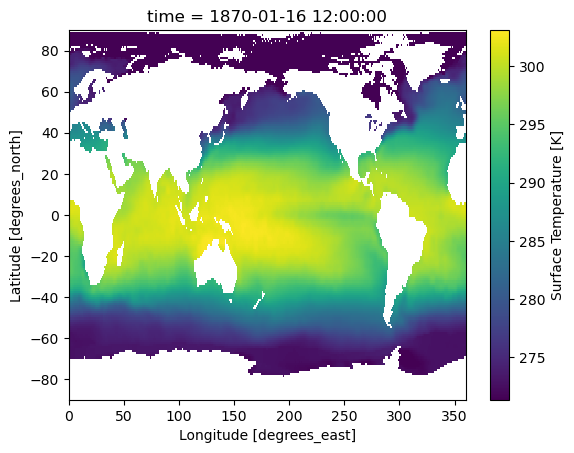

In [5]:
ds[data_var].isel(time=0).plot()

## 2. Spatial Average

### 2.1 Default average

In [6]:
ds.isel(time=0).spatial.average(data_var)[data_var].item()

291.17218278759884

### 2.2 Find data coverage by number of grid point

Limit by fraction of data coverage calculated by number of grid points supposed to NOT work, because actual grid area weight is considered.

In [14]:
# Count nan in the data
ds0 = ds.isel(time=0)
data = ds0[data_var]

total_values = data.size
nan_count = data.isnull().sum().item()
coverage_fraction = (total_values - nan_count) / total_values

print(f"Total number of values (by grid point): {total_values}")
print(f"Number of NaN values (by grid point): {nan_count}")
print(f"Data coverage fraction (by grid point): {coverage_fraction}")

Total number of values (by grid point): 64800
Number of NaN values (by grid point): 22454
Data coverage fraction (by grid point): 0.6534876543209877


In [8]:
ds.isel(time=0).spatial.average(data_var, min_weight=0.6)[data_var].item()

291.17218278759884

### 2.3 Check data coverage by area weight

In [28]:
# Calculate weights based on the area represented by each grid point
weights = np.cos(np.deg2rad(data["lat"]))  # Cosine of latitude (in radians)

# Add weights as a DataArray
weights_da = xr.DataArray(weights, coords={"lat": data["lat"]}, dims=["lat"])

# Broadcast weights across longitude
weights_2d = weights_da.expand_dims(dim={"lon": data["lon"]})

# Mask weights where data is NaN
weights_nan = weights_2d.where(data.isnull())

# Sum of weights where data is NaN
sum_weights_nan = weights_nan.sum()

# Sum of weights from all grid points
sum_weights_2d = weights_2d.sum()

# Coverage fraction
coverage_fraction_by_wgt = (sum_weights_2d.values - sum_weights_nan.values) / sum_weights_2d.values

print(f"Sum of weights where data is NaN: {sum_weights_nan.values}")
print(f"Sum of all weights: {sum_weights_2d.values}")
print(f"Data coverage fraction (by weight): {coverage_fraction_by_wgt}")

Sum of weights where data is NaN: 11513.040731745683
Sum of all weights: 41253.4848528469
Data coverage fraction (by weight): 0.7209195593338784


In [10]:
ds.isel(time=0).spatial.average(data_var, min_weight=0.72)[data_var].item()

291.17218278759884

In [11]:
ds.isel(time=0).spatial.average(data_var, min_weight=0.73)[data_var].item()

nan